# Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path


import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset, random_split
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import time


Importing important required libraries

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Fixes the randoom seed values for PyTorch and NumPy for consistent results.

# Device Setup

In [3]:
# Device configuration - prioritize MPS (Metal Performance Shaders) for Mac
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


Notebook is using GPU

# Dataset path

In [4]:
# Base path
BASE_PATH = "/Users/shreyash/Documents/Sem3DL/AT2DL"
DATA_PATH = os.path.join(BASE_PATH, "food-101")

# Verify dataset path
print("Dataset path exists:", os.path.exists(DATA_PATH))
print("")
# Check dataset structure
print("Top-level folders:")
print(os.listdir(DATA_PATH))

Dataset path exists: True

Top-level folders:
['.DS_Store', 'images', 'meta', 'license_agreement.txt', 'README.txt']


Dataset path validation check.

# Exploratory Data Analysis (EDA)

Total training samples : 75750
Total test samples     : 25250
Number of classes      : 101

Training samples per class : min: 750, max: 750, mean: 750.0
Test samples per class     : min: 250,  max: 250,  mean: 250.0


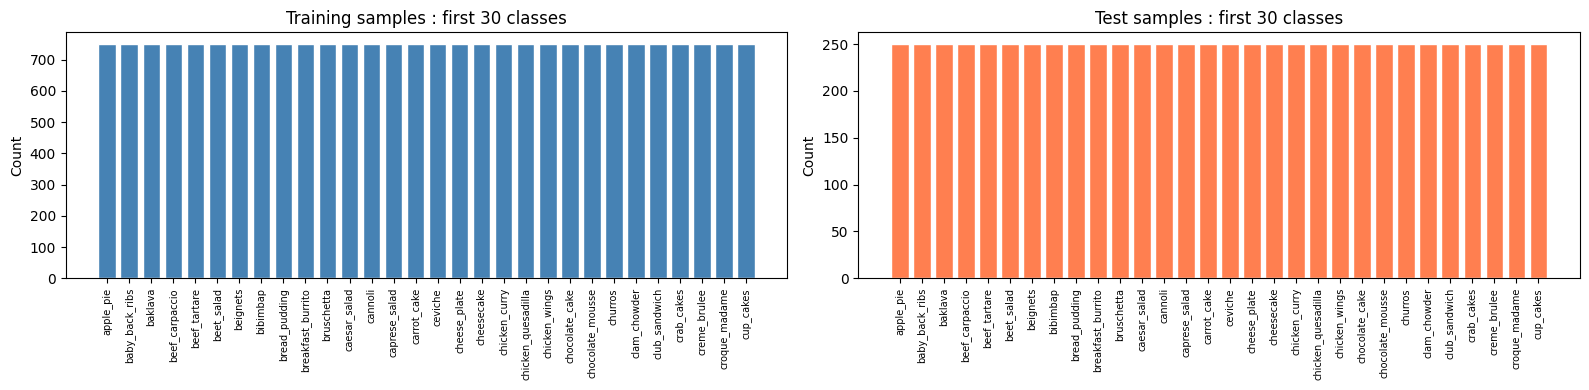

Food101 is balanced and each class has exactly 750 train and 250 test images.


In [5]:
meta_path = os.path.join(DATA_PATH, "meta")

with open(os.path.join(meta_path, "classes.txt")) as f:
    classes = [line.strip() for line in f.readlines()]

with open(os.path.join(meta_path, "train.txt")) as f:
    train_paths = [line.strip() for line in f.readlines()]

with open(os.path.join(meta_path, "test.txt")) as f:
    test_paths = [line.strip() for line in f.readlines()]

# Count samples per class
train_counts = pd.Series([p.split("/")[0] for p in train_paths]).value_counts().sort_index()
test_counts  = pd.Series([p.split("/")[0] for p in test_paths]).value_counts().sort_index()

print(f"Total training samples : {len(train_paths)}")
print(f"Total test samples     : {len(test_paths)}")
print(f"Number of classes      : {len(classes)}")
print(f"\nTraining samples per class : min: {train_counts.min()}, max: {train_counts.max()}, mean: {train_counts.mean():.1f}")
print(f"Test samples per class     : min: {test_counts.min()},  max: {test_counts.max()},  mean: {test_counts.mean():.1f}")

# Plot class distribution (first 30 classes for readability)
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].bar(range(30), train_counts.values[:30], color="steelblue", edgecolor="white")
axes[0].set_xticks(range(30))
axes[0].set_xticklabels(train_counts.index[:30], rotation=90, fontsize=7)
axes[0].set_title("Training samples : first 30 classes")
axes[0].set_ylabel("Count")

axes[1].bar(range(30), test_counts.values[:30], color="coral", edgecolor="white")
axes[1].set_xticks(range(30))
axes[1].set_xticklabels(test_counts.index[:30], rotation=90, fontsize=7)
axes[1].set_title("Test samples : first 30 classes")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("eda_class_distribution.png", dpi=100, bbox_inches="tight")
plt.show()
print("Food101 is balanced and each class has exactly 750 train and 250 test images.")

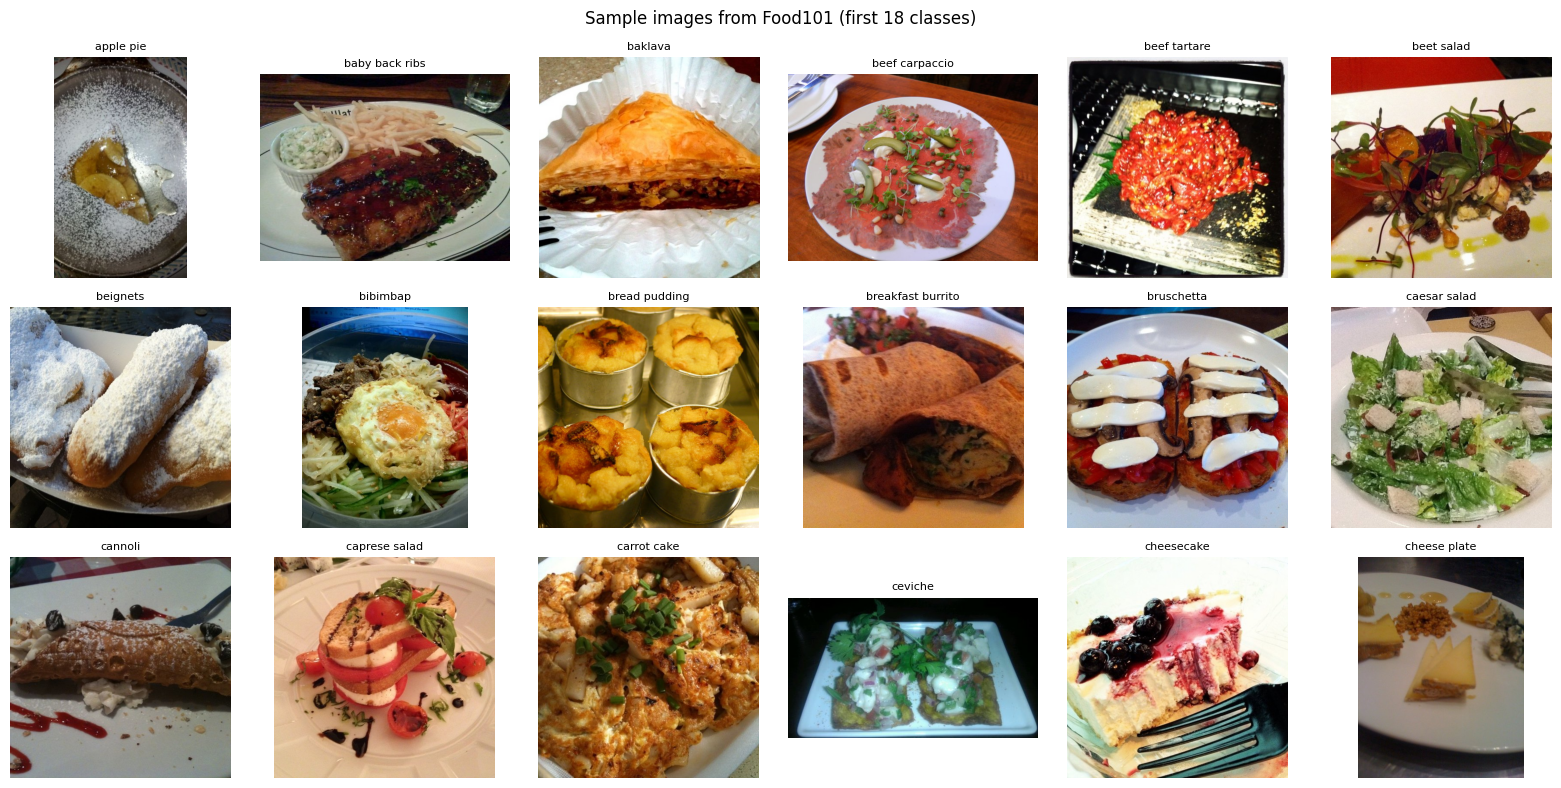

In [6]:
fig, axes = plt.subplots(3, 6, figsize=(16, 8))
sample_classes = classes[:18]

for ax, cls in zip(axes.flatten(), sample_classes):
    # pick the first image for each class
    img_name = [p for p in train_paths if p.startswith(cls + "/")][0]
    img_path = os.path.join(DATA_PATH, "images", img_name + ".jpg")
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(cls.replace("_", " "), fontsize=8)
    ax.axis("off")

plt.suptitle("Sample images from Food101 (first 18 classes)", fontsize=12)
plt.tight_layout()
plt.savefig("eda_sample_images.png", dpi=100, bbox_inches="tight")
plt.show()

# Dataset Preprocessing:

In [7]:
class Food101Dataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = root_dir
        self.transform = transform

        meta_path = os.path.join(root_dir, "meta")
        file_path = os.path.join(meta_path, f"{split}.txt")

        with open(file_path, "r") as f:
            self.image_paths = [line.strip() for line in f.readlines()]

        with open(os.path.join(meta_path, "classes.txt"), "r") as f:
            self.classes = [line.strip() for line in f.readlines()]

        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_rel_path = self.image_paths[idx]
        label_name = img_rel_path.split('/')[0]

        img_path = os.path.join(self.root_dir, "images", img_rel_path + ".jpg")
        image = Image.open(img_path).convert("RGB")

        label = self.class_to_idx[label_name]

        if self.transform:
            image = self.transform(image)

        return image, label

Custom PyTorch dataset for Food101

# Normalize and Transforms

In [8]:
# ImageNet normalization values
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Training transforms (with augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# Test transforms (no augmentation)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

Preprocessesing step for training and test images transformed: resized and normalized (training are lighly augmented with flip and rotation)

# Load Dataset

In [9]:
#train_dir = os.path.join(DATA_PATH, "train")
#test_dir = os.path.join(DATA_PATH, "test")

#train_dataset = Food101Dataset(DATA_PATH, split='train', transform=train_transforms)
#test_dataset = Food101Dataset(DATA_PATH, split='test', transform=test_transforms)

#print("Training samples:", len(train_dataset))
#print("Test samples:", len(test_dataset))
#print("Number of classes:", len(train_dataset.classes))

In [9]:
train_dir = os.path.join(DATA_PATH, "train")
test_dir = os.path.join(DATA_PATH, "test")

full_train_dataset = Food101Dataset(DATA_PATH, split='train', transform=train_transforms)
test_dataset = Food101Dataset(DATA_PATH, split='test', transform=test_transforms)

BATCH_SIZE = 32
VAL_FRACTION = 0.15     # 15% of training data held out as validation

# train / val split
n_total = len(full_train_dataset)
n_val   = int(n_total * VAL_FRACTION)
n_train = n_total - n_val

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

# Override val transform — no augmentation on validation images
val_dataset.dataset.transform = test_transforms

print(f"Training   samples : {n_train}")
print(f"Validation samples : {n_val}")
print(f"Test       samples : {len(test_dataset)}")
print(f"Number of classes  : {len(full_train_dataset.classes)}")

Training   samples : 64388
Validation samples : 11362
Test       samples : 25250
Number of classes  : 101


# Batch size and DataLoaders

In [11]:
#BATCH_SIZE = 32

#train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
#test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [12]:
#train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
#                          num_workers=4, pin_memory=True)

#val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
#                        num_workers=4, pin_memory=True)

#test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
#                         num_workers=4, pin_memory=True)

In [10]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=0, pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)

In [11]:
# Sanity check
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape} = [{BATCH_SIZE}, 3, 224, 224]")
print(f"Labels shape: {labels.shape} = [{BATCH_SIZE}]")

Batch shape: torch.Size([32, 3, 224, 224]) = [32, 3, 224, 224]
Labels shape: torch.Size([32]) = [32]


/Users/shreyash/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Each batch has 32 RGB images, resized to 224x224.

# Model Function

### Transfer Learning Setup

Pre-trained convolutional neural networks trained on ImageNet are used as feature extractors.

All backbone layers are frozen to retain learned visual features such as edges, textures, and shapes. Only the final classification head is replaced and trained on the Food101 dataset.

Each new head consists of three fully connected layers, allowing the model to adapt to 101 food categories without retraining the entire network.

In [12]:
NUM_CLASSES = 101

In [13]:
def build_classification_head(in_features: int, num_classes: int) -> nn.Sequential:
    """Three-layer FC head with ReLU, BatchNorm and Dropout."""
    return nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )

In [14]:
def get_model(model_name, num_classes=101):
    if model_name == "resnet":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        in_features = model.fc.in_features

        # Freeze backbone
        for param in model.parameters():
            param.requires_grad = False

        # Replace head
        model.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    elif model_name == "googlenet":
        model = models.googlenet(weights=models.GoogLeNet_Weights.DEFAULT)
        in_features = model.fc.in_features

        for param in model.parameters():
            param.requires_grad = False

        model.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    elif model_name == "mobilenet":
        model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        in_features = model.classifier[0].in_features

        for param in model.parameters():
            param.requires_grad = False

        model.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    else:
        raise ValueError("Invalid model name")

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"[{model_name}] Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

    return model.to(device)

Function to call 3 pre-trained models: ResNet, GoogLeNet, or MobileNetV3.

Freezed the pretrained backbone layers and replaced the original classifier with a new three-layer fully connected head.

# Initializing Models

In [15]:
resnet_model = get_model("resnet")
googlenet_model = get_model("googlenet")
mobilenet_model = get_model("mobilenet")

print("Models initialized successfully")

[resnet] Trainable params: 1,206,373 / 24,714,405 (4.9%)
[googlenet] Trainable params: 682,085 / 6,281,989 (10.9%)
[mobilenet] Trainable params: 452,709 / 1,379,717 (32.8%)
Models initialized successfully


### Model Architectures

Three different pre-trained architectures are used to compare performance under the same transfer learning setup.

- ResNet uses skip connections that allow deeper networks to learn effectively.
- GoogLeNet uses Inception modules to process multiple feature scales in parallel.
- MobileNetV3 is designed for efficiency using lightweight operations and optimized blocks.

These models differ in complexity, parameter size, and learning behavior, making them suitable for comparison.

# Training Models:

In [16]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=10,
    lr=1e-3,
    model_name="model",
    save_path=None,
    use_scheduler=True,
):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )

    scheduler = None
    if use_scheduler:
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_state = None

    for epoch in range(epochs):
        t0 = time.time()

        # Training 
        model.train()
        run_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            # Handle GoogLeNet
            if hasattr(outputs, "logits"):
                outputs = outputs.logits
            elif isinstance(outputs, tuple):
                outputs = outputs[0]

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            run_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = run_loss / total
        train_acc = 100.0 * correct / total

        # Validation
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)

                if hasattr(outputs, "logits"):
                    outputs = outputs.logits
                elif isinstance(outputs, tuple):
                    outputs = outputs[0]

                loss = criterion(outputs, labels)

                v_loss += loss.item() * images.size(0)
                _, pred = outputs.max(1)
                v_total += labels.size(0)
                v_correct += pred.eq(labels).sum().item()

        val_loss = v_loss / v_total
        val_acc = 100.0 * v_correct / v_total

        if scheduler:
            scheduler.step()

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

            # Save to disk for later tuning phase
            if save_path:
                torch.save({
                    "model_state_dict": best_state,
                    "val_acc": best_val_acc,
                    "model_name": model_name
                }, save_path)

        # Best values:
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        elapsed = time.time() - t0
        print(f"[{model_name}] Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
              f"Time: {elapsed:.1f}s")

    # Restore best weights
    model.load_state_dict(best_state)

    print(f"\n[{model_name}] Best Val Acc: {best_val_acc:.2f}% (restored)\n")

    return model, history, best_val_acc

Training is performed using cross-entropy loss, which is suitable for multi-class classification problems.

The Adam optimizer is used to update only the parameters of the new classification head. The pretrained backbone remains frozen throughout training.

The models are trained for 10 epochs with a batch size of 32. Performance is evaluated using accuracy on the test set after each epoch.

## Eval Function:

In [17]:
def evaluate_on_test(model, test_loader, class_names):
    model.eval()
    all_preds, all_labels = [], []
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            # Handle GoogLeNet outputs
            if hasattr(outputs, "logits"):
                outputs = outputs.logits
            elif isinstance(outputs, tuple):
                outputs = outputs[0]

            # Standard prediction (Accuracy)
            _, preds = outputs.max(1)

            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100.0 * correct / total

    print(f"  Test Accuracy : {accuracy:.2f}%")

    return accuracy, all_preds, all_labels


def plot_training_curves(history, model_name):
    """Plot loss and accuracy curves for train and validation splits."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Loss
    axes[0].plot(epochs, history["train_loss"], "o-", label="Train loss",  color="steelblue")
    axes[0].plot(epochs, history["val_loss"],   "s--", label="Val loss",   color="coral")
    axes[0].set_title(f"{model_name} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-entropy loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history["train_acc"], "o-",  label="Train acc",  color="steelblue")
    axes[1].plot(epochs, history["val_acc"],   "s--", label="Val acc",    color="coral")
    axes[1].set_title(f"{model_name} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle(f"Training curves — {model_name}", fontsize=13)
    plt.tight_layout()
    #plt.savefig(f"curves_{model_name}.png", dpi=100, bbox_inches="tight")
    plt.show()


def plot_confusion_matrix(all_labels, all_preds, class_names, model_name, top_n=20):
    """Plot a confusion matrix for the top_n most-confused classes."""
    cm = confusion_matrix(all_labels, all_preds)

    # Select top_n classes by total errors
    errors = cm.sum(axis=1) - np.diag(cm)
    top_idx = np.argsort(errors)[-top_n:][::-1]

    cm_sub = cm[np.ix_(top_idx, top_idx)]
    labels_sub = [class_names[i].replace("_", " ") for i in top_idx]

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm_sub, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_sub, yticklabels=labels_sub, ax=ax,
                linewidths=0.4, linecolor="white")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{model_name} — Confusion matrix (top {top_n} most-confused classes)")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    #plt.savefig(f"cm_{model_name}.png", dpi=100, bbox_inches="tight")
    plt.show()

## 1. ResNet training:

In [18]:
trained_resnet, resnet_history, resnet_best_acc = train_model(
    resnet_model,
    train_loader,
    val_loader,
    epochs=10,
    model_name="ResNet-50",
    save_path="resnet50_best.pth"
)

[ResNet-50] Epoch 01/10 | Train Loss: 2.8001 Acc: 31.56% | Val Loss: 1.9849 Acc: 49.21% | Time: 955.0s
[ResNet-50] Epoch 02/10 | Train Loss: 2.1135 Acc: 46.28% | Val Loss: 1.8430 Acc: 53.30% | Time: 959.6s
[ResNet-50] Epoch 03/10 | Train Loss: 1.9195 Acc: 50.73% | Val Loss: 1.7871 Acc: 54.74% | Time: 968.4s
[ResNet-50] Epoch 04/10 | Train Loss: 1.6607 Acc: 56.59% | Val Loss: 1.6782 Acc: 57.75% | Time: 1314.1s
[ResNet-50] Epoch 05/10 | Train Loss: 1.5551 Acc: 58.69% | Val Loss: 1.6842 Acc: 56.93% | Time: 641.2s
[ResNet-50] Epoch 06/10 | Train Loss: 1.4755 Acc: 60.58% | Val Loss: 1.6566 Acc: 58.11% | Time: 798.8s
[ResNet-50] Epoch 07/10 | Train Loss: 1.3599 Acc: 63.35% | Val Loss: 1.6136 Acc: 59.12% | Time: 778.9s
[ResNet-50] Epoch 08/10 | Train Loss: 1.3085 Acc: 64.56% | Val Loss: 1.6340 Acc: 58.53% | Time: 871.2s
[ResNet-50] Epoch 09/10 | Train Loss: 1.2711 Acc: 65.31% | Val Loss: 1.6237 Acc: 59.26% | Time: 792.7s
[ResNet-50] Epoch 10/10 | Train Loss: 1.2017 Acc: 66.96% | Val Loss: 1.6

ResNet shows steady learning, with validation accuracy improving consistently across 10 epochs.

Validation accuracy increases in early epochs but plateaus around 59%, suggesting that the model begins to overfit slightly after mid-training. The gap between training and validation accuracy in later epochs indicates limited generalization improvement beyond this point.

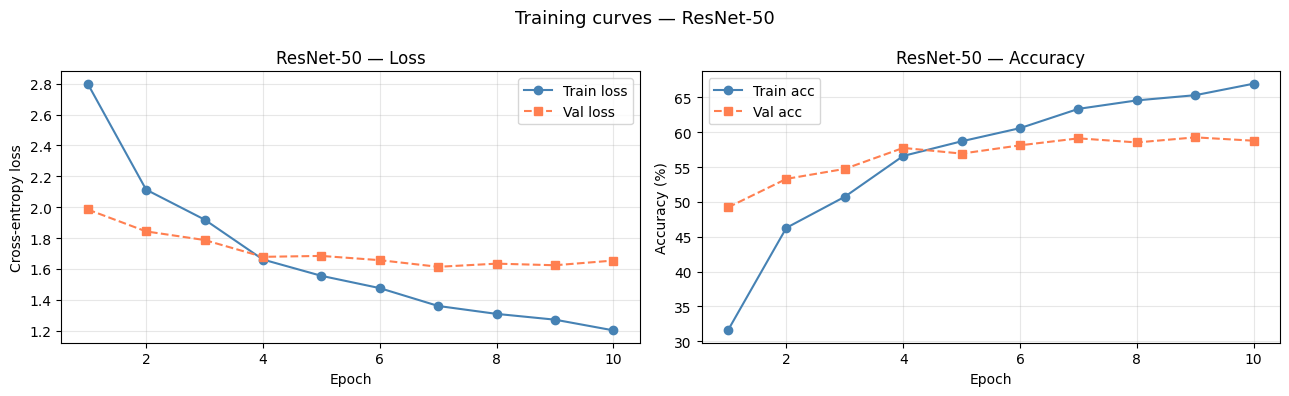

In [19]:
plot_training_curves(resnet_history, "ResNet-50")

## Evaluating ResNet

  Test Accuracy : 64.45%


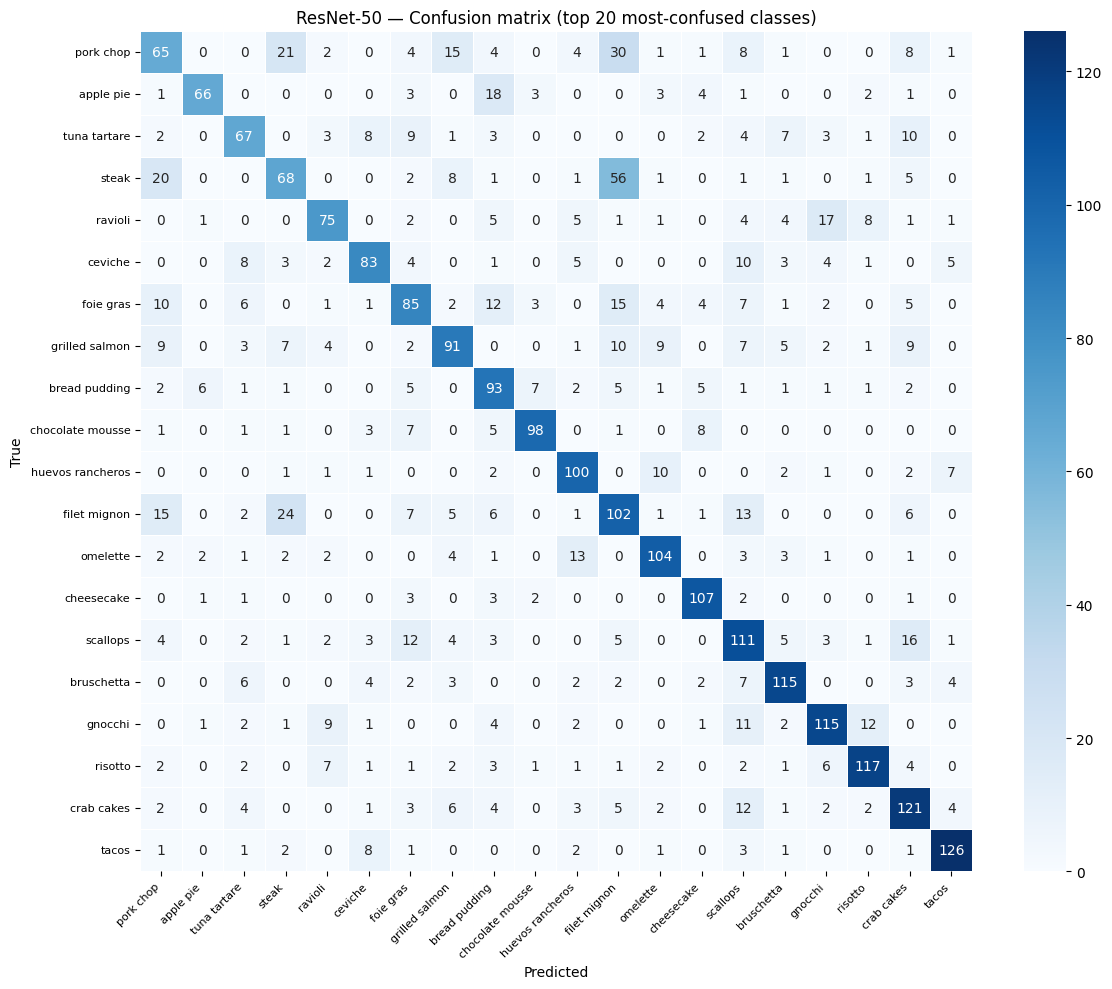

In [20]:
resnet_acc, resnet_preds, resnet_labels = evaluate_on_test(
    trained_resnet,
    test_loader,
    class_names=full_train_dataset.classes
)

#plot_training_curves(resnet_history, "ResNet-50")
plot_confusion_matrix(resnet_labels, resnet_preds, full_train_dataset.classes, "ResNet-50")

Model Accuracy: 64.45% shows the final ResNet test performance is very impressive.
This means the frozen ResNet backbone plus custom head can classify Food101 at a better level as of now.

## 2. Training GoogLeNet:

In [21]:
trained_googlenet, googlenet_history, googlenet_best_acc = train_model(
    googlenet_model,
    train_loader,
    val_loader,
    epochs=10,
    model_name="GoogLeNet",
    save_path="googlenet_best.pth"
)

/Users/shreyash/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[GoogLeNet] Epoch 01/10 | Train Loss: 3.5816 Acc: 15.78% | Val Loss: 2.8640 Acc: 30.69% | Time: 437.9s
[GoogLeNet] Epoch 02/10 | Train Loss: 3.0988 Acc: 24.68% | Val Loss: 2.6623 Acc: 34.93% | Time: 408.1s
[GoogLeNet] Epoch 03/10 | Train Loss: 2.9894 Acc: 27.29% | Val Loss: 2.6088 Acc: 37.01% | Time: 459.4s
[GoogLeNet] Epoch 04/10 | Train Loss: 2.8694 Acc: 29.58% | Val Loss: 2.4724 Acc: 39.22% | Time: 407.8s
[GoogLeNet] Epoch 05/10 | Train Loss: 2.8172 Acc: 30.67% | Val Loss: 2.4666 Acc: 40.49% | Time: 407.7s
[GoogLeNet] Epoch 06/10 | Train Loss: 2.8064 Acc: 30.95% | Val Loss: 2.4637 Acc: 39.83% | Time: 431.1s
[GoogLeNet] Epoch 07/10 | Train Loss: 2.7439 Acc: 32.39% | Val Loss: 2.3908 Acc: 41.05% | Time: 452.3s
[GoogLeNet] Epoch 08/10 | Train Loss: 2.7352 Acc: 32.43% | Val Loss: 2.3902 Acc: 41.30% | Time: 405.6s
[GoogLeNet] Epoch 09/10 | Train Loss: 2.7270 Acc: 32.89% | Val Loss: 2.3774 Acc: 42.09% | Time: 451.9s
[GoogLeNet] Epoch 10/10 | Train Loss: 2.6921 Acc: 33.59% | Val Loss: 2.37

GoogLeNet learns more slowly compared to ResNet and reaches a lower final accuracy.

The Inception structure processes multiple feature scales, but this complexity does not translate well when the backbone is frozen.

This suggests that GoogLeNet may require more fine-tuning to perform better on this dataset.

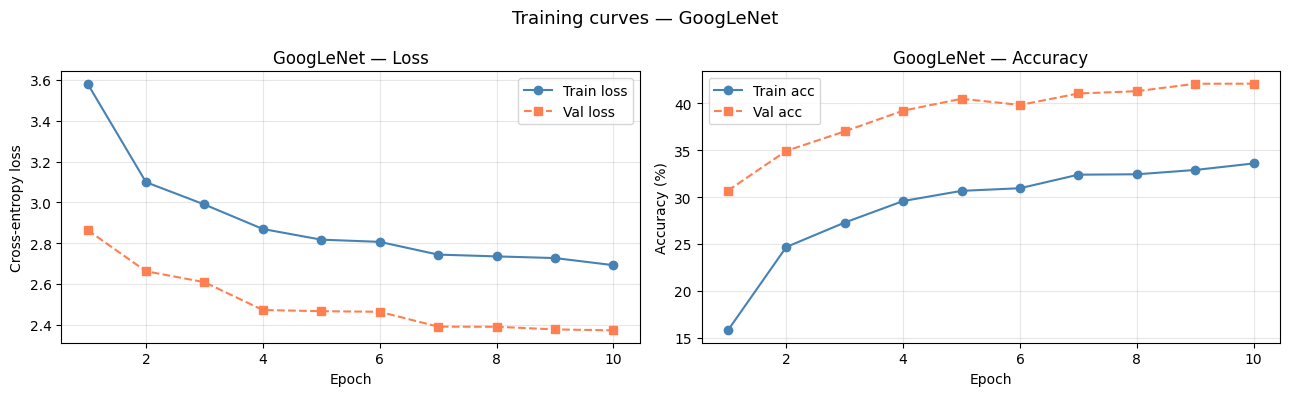

In [22]:
plot_training_curves(googlenet_history, "GoogLeNet")

## Evaluating GoogLeNet

  Test Accuracy : 45.83%


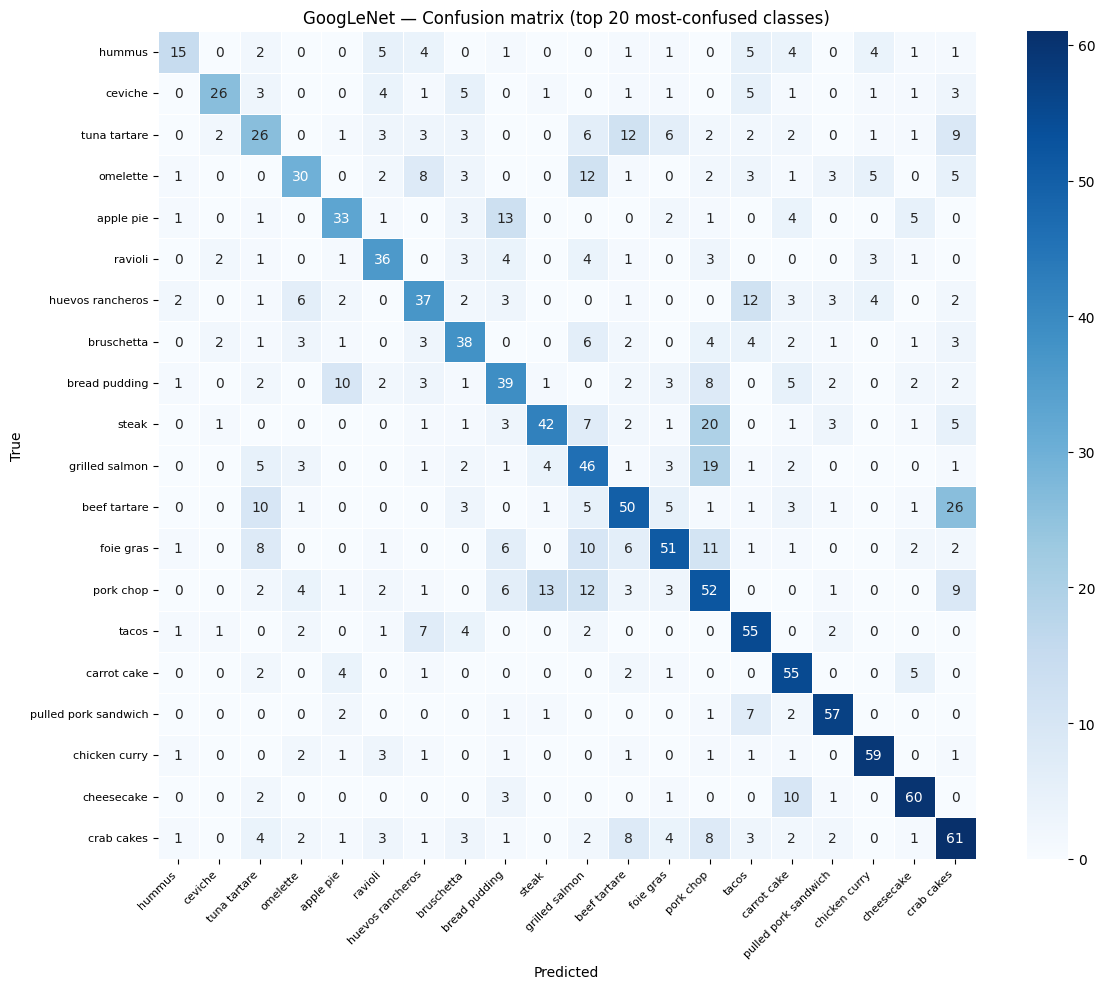

In [23]:
googlenet_acc, googlenet_preds, googlenet_labels = evaluate_on_test(
    trained_googlenet,
    test_loader,
    class_names=full_train_dataset.classes
)
#plot_training_curves(googlenet_history, "GoogLeNet")
plot_confusion_matrix(googlenet_labels, googlenet_preds, full_train_dataset.classes, "GoogLeNet")

Model Accuracy: 45.83% shows GoogLeNet had the lowest final score among the models tested so far.
It still learned the task, but its performance was weaker than ResNet.

## 3. Training MobileNetV3

In [24]:
trained_mobilenet, mobilenet_history, mobilenet_best_acc = train_model(
    mobilenet_model,
    train_loader,
    val_loader,
    epochs=10,
    model_name="MobileNetV3",
    save_path="mobilenetv3_best.pth"
)

/Users/shreyash/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[MobileNetV3] Epoch 01/10 | Train Loss: 3.3082 Acc: 21.39% | Val Loss: 2.6327 Acc: 35.15% | Time: 264.8s
[MobileNetV3] Epoch 02/10 | Train Loss: 2.7594 Acc: 32.46% | Val Loss: 2.4346 Acc: 40.11% | Time: 263.9s
[MobileNetV3] Epoch 03/10 | Train Loss: 2.6047 Acc: 35.76% | Val Loss: 2.3522 Acc: 42.05% | Time: 264.3s
[MobileNetV3] Epoch 04/10 | Train Loss: 2.4138 Acc: 39.73% | Val Loss: 2.2086 Acc: 45.17% | Time: 263.9s
[MobileNetV3] Epoch 05/10 | Train Loss: 2.3385 Acc: 41.51% | Val Loss: 2.1604 Acc: 46.52% | Time: 268.0s
[MobileNetV3] Epoch 06/10 | Train Loss: 2.2889 Acc: 42.54% | Val Loss: 2.1507 Acc: 46.57% | Time: 261.5s
[MobileNetV3] Epoch 07/10 | Train Loss: 2.1934 Acc: 44.58% | Val Loss: 2.1000 Acc: 47.48% | Time: 262.0s
[MobileNetV3] Epoch 08/10 | Train Loss: 2.1528 Acc: 45.40% | Val Loss: 2.0770 Acc: 48.09% | Time: 262.8s
[MobileNetV3] Epoch 09/10 | Train Loss: 2.1273 Acc: 45.77% | Val Loss: 2.0560 Acc: 48.70% | Time: 262.6s
[MobileNetV3] Epoch 10/10 | Train Loss: 2.0670 Acc: 47.

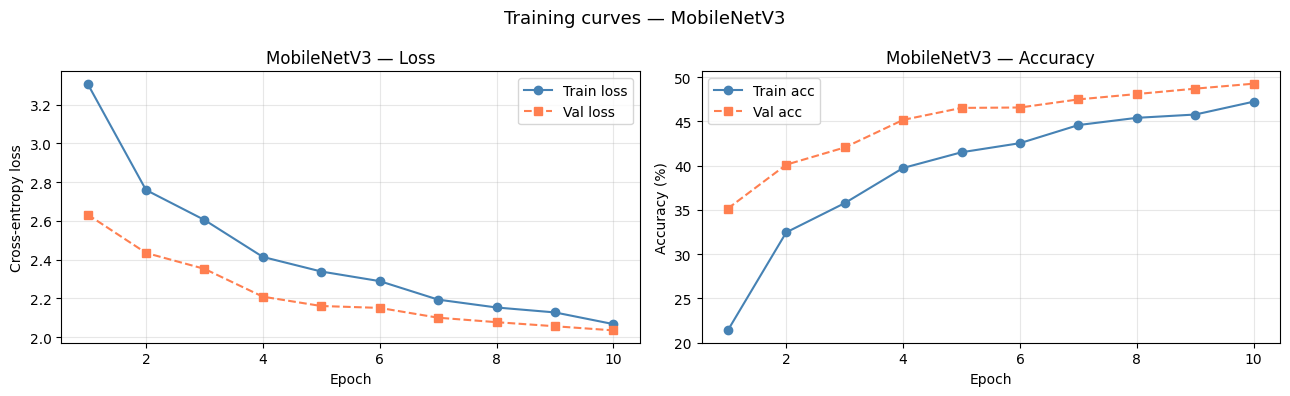

In [25]:
plot_training_curves(mobilenet_history, "MobileNetV3")

## Evaluating MobileNetV3

  Test Accuracy : 54.02%


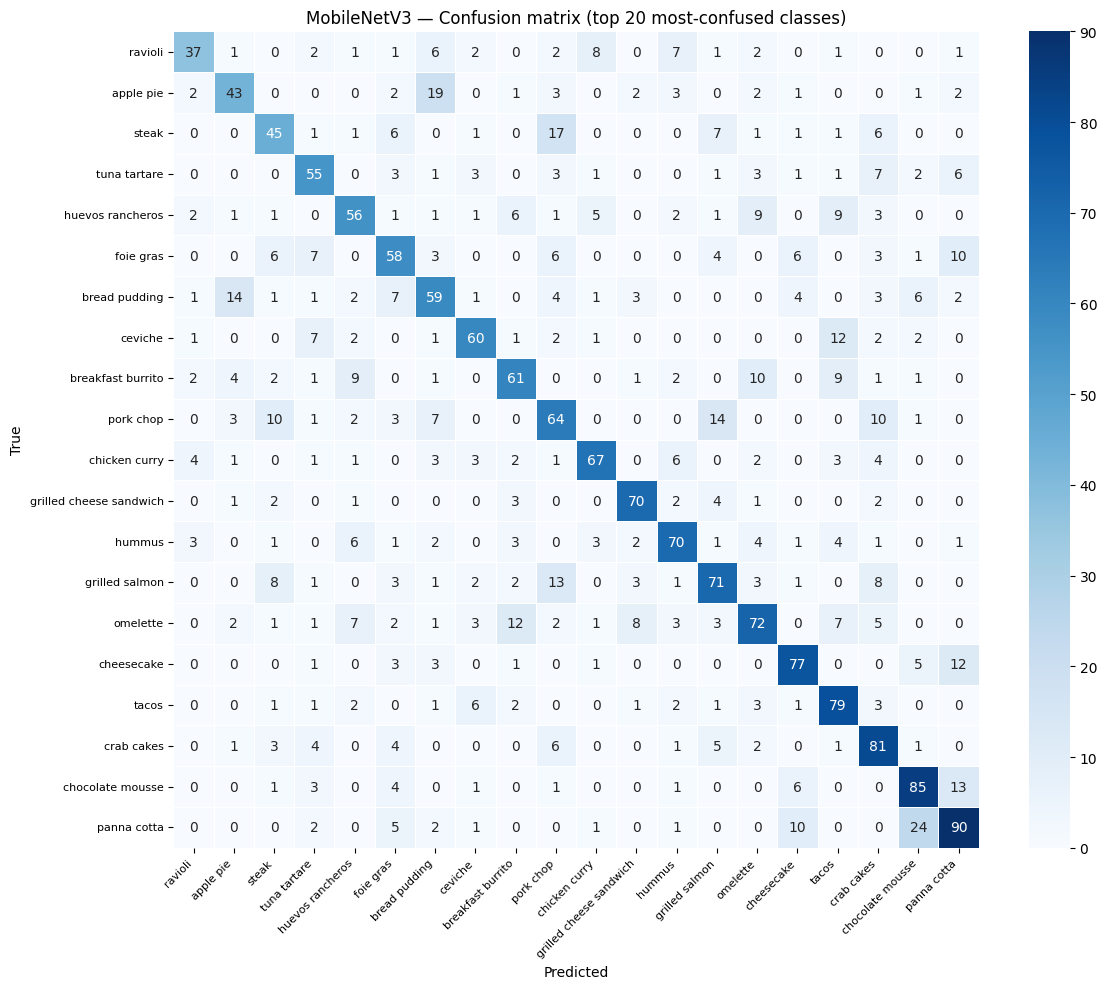

In [26]:
mobilenet_acc, mobilenet_preds, mobilenet_labels = evaluate_on_test(
    trained_mobilenet,
    test_loader,
    class_names=full_train_dataset.classes
)

plot_confusion_matrix(
    mobilenet_labels,
    mobilenet_preds,
    class_names=full_train_dataset.classes,
    model_name="MobileNetV3"
)

Model Accuracy: 54.02% shows MobileNetV3 is performing better than GoogLeNet model in Part A.
This means it gave the clear idea that ResNet model leds the classification performance with the frozen pretrained backbone.

# Test Accuracy Comparison

In [27]:
print(f"ResNet-50 Accuracy: {resnet_acc:.2f}%")
print(f"GoogLeNet Accuracy: {googlenet_acc:.2f}%")
print(f"MobileNetV3 Accuracy: {mobilenet_acc:.2f}%")

ResNet-50 Accuracy: 64.45%
GoogLeNet Accuracy: 45.83%
MobileNetV3 Accuracy: 54.02%


In [28]:
results = pd.DataFrame({
    "Model": ["ResNet-50", "GoogLeNet", "MobileNetV3"],
    "Test Accuracy (%)": [resnet_acc, googlenet_acc, mobilenet_acc]
})

print(results)

         Model  Test Accuracy (%)
0    ResNet-50          64.451485
1    GoogLeNet          45.833663
2  MobileNetV3          54.023762


# Model Comparison and Performance Analysis

# Performance Summary

| Model         | Test Accuracy (%) |
|--------------|------------------|
| ResNet-50    | 64.45            |
| MobileNetV3  | 45.83            |
| GoogLeNet    | 54.02            |

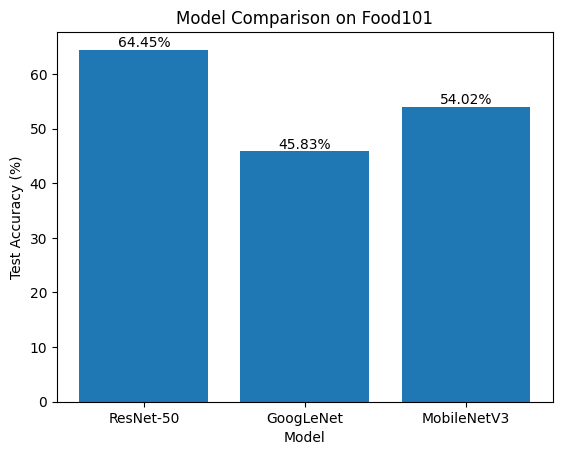

In [30]:
model_names = results["Model"]
accuracies = results["Test Accuracy (%)"]

plt.figure()
plt.bar(model_names, accuracies)

plt.title("Model Comparison on Food101")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")

# Add value labels on bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.show()

# Conclusion

Among the three models, ResNet-50 provided the best trade-off between efficiency and accuracy, making it the most suitable candidate for further fine-tuning in Part B of this assignment.